In [ ]:
import os
from openai import OpenAI


import json
import time
import torch
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.metrics import roc_curve, auc
from transformers import AutoModelForCausalLM, AutoTokenizer, LogitsProcessorList
import json
# 从 main.py 导入
from fc import (
    KGWLogitsProcessor, UnbiasedLogitsProcessor, 
    KGWDetector, UnbiasedDetector, 
    WatermarkEngine, Evaluator,
    plot_comprehensive_results, print_evaluation_report
)




def length_sensitivity_experiment(engine, prompts, tokenizer, device):
    print("\n>>> Length Sensitivity Experiment")

    kgw_proc = KGWLogitsProcessor(gamma=0.5, delta=2.0, device=device)
    kgw_det = KGWDetector(tokenizer, device=device)

    lengths = [16, 32, 64, 128, 256]
    results = []

    for L in lengths:
        gen_config = {
            "max_new_tokens": L,
            "do_sample": True,
            "temperature": 0.7,
            "top_p": 0.9,
            "pad_token_id": tokenizer.pad_token_id,
        }

        data = engine.generate(prompts, {"kgw": kgw_proc}, gen_config, batch_size=8)

        z_scores = []
        for item in data:
            z = kgw_det.detect(item["tokens"]["kgw"], item["prompt_len"])
            z_scores.append(z)

        avg_z = np.mean(z_scores)

        results.append((L, avg_z))
        print(f"Length {L}: Z = {avg_z:.2f}")

    return results

def plot_length_sensitivity(results):
    import matplotlib.pyplot as plt

    lengths = [r[0] for r in results]
    z_vals = [r[1] for r in results]

    plt.figure()
    plt.plot(lengths, z_vals, marker='o')

    plt.xlabel("Generated Length")
    plt.ylabel("Z-score")
    plt.title("Length Sensitivity (KGW)")

    plt.grid()
    plt.show()

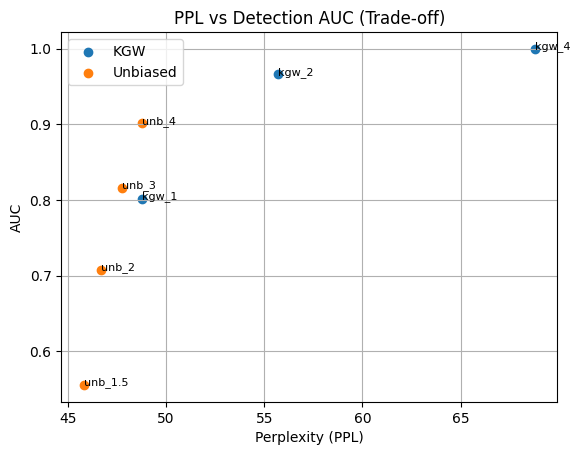

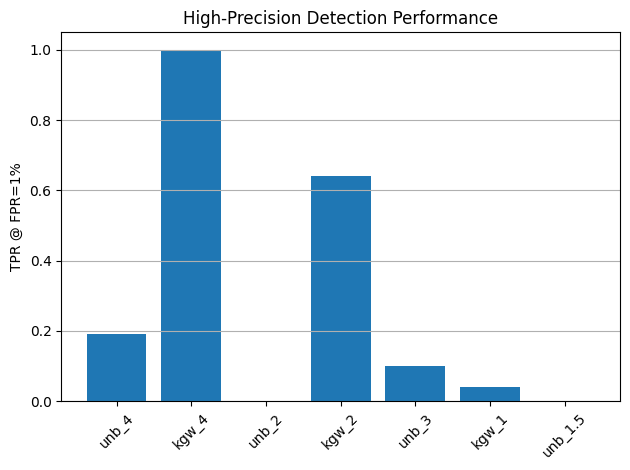

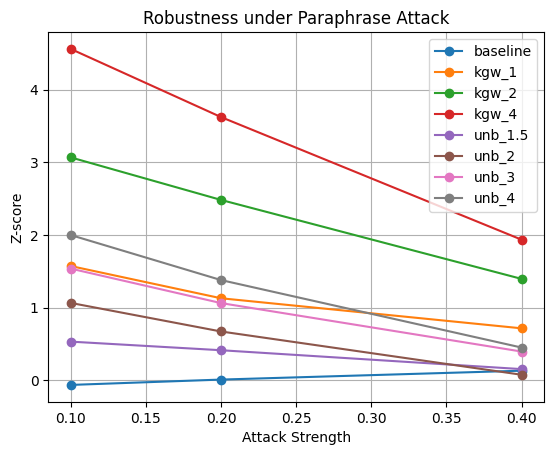

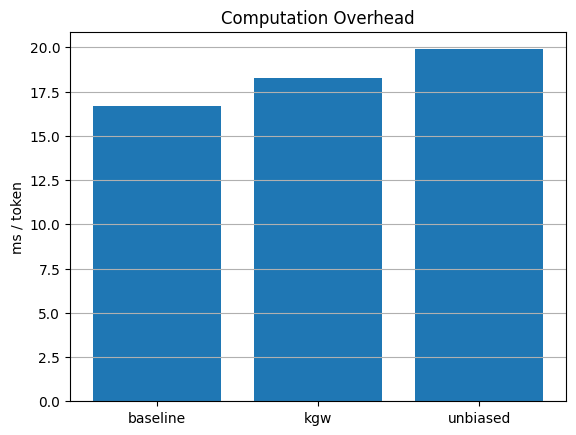

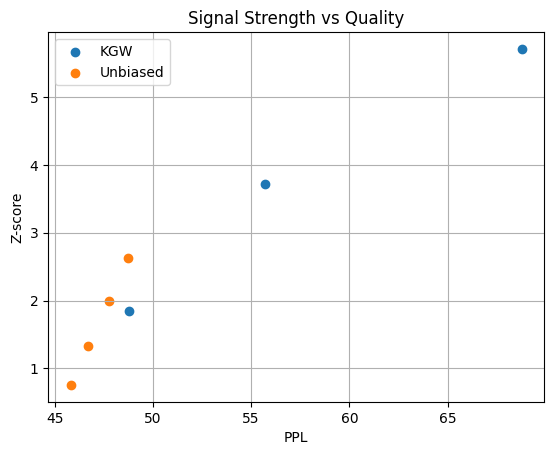

All plots saved.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

# =========================
# 1. 读取数据
# =========================
df_det = pd.read_csv("detection.csv")
df_rob = pd.read_csv("robustness.csv")
df_over = pd.read_csv("overhead.csv")

# 分类方法
def get_type(name):
    if "kgw" in name:
        return "KGW"
    elif "unb" in name:
        return "Unbiased"
    else:
        return "Baseline"

df_det["type"] = df_det["method"].apply(get_type)

# =========================
# 2. PPL vs AUC（核心图）
# =========================
plt.figure()

for t in ["KGW", "Unbiased"]:
    sub = df_det[df_det["type"] == t]
    plt.scatter(sub["ppl"], sub["auc"], label=t)
    
    for _, row in sub.iterrows():
        plt.text(row["ppl"], row["auc"], row["method"], fontsize=8)

plt.xlabel("Perplexity (PPL)")
plt.ylabel("AUC")
plt.title("PPL vs Detection AUC (Trade-off)")
plt.legend()
plt.grid()
plt.savefig("tradeoff_ppl_auc.png", dpi=300)
plt.show()
plt.close()

# =========================
# 3. TPR@1% 对比
# =========================
plt.figure()

df_plot = df_det[df_det["type"] != "Baseline"]
x = np.arange(len(df_plot))

plt.bar(x, df_plot["tpr@1%"])
plt.xticks(x, df_plot["method"], rotation=45)
plt.ylabel("TPR @ FPR=1%")
plt.title("High-Precision Detection Performance")
plt.grid(axis="y")

plt.tight_layout()
plt.savefig("tpr_at_1.png", dpi=300)
plt.show()
plt.close()

# =========================
# 4. 鲁棒性曲线
# =========================
plt.figure()

for method in df_rob["method"].unique():
    sub = df_rob[df_rob["method"] == method]
    plt.plot(sub["attack"], sub["z"], marker='o', label=method)

plt.xlabel("Attack Strength")
plt.ylabel("Z-score")
plt.title("Robustness under Paraphrase Attack")
plt.legend()
plt.grid()
plt.savefig("robustness.png", dpi=300)
plt.show()
plt.close()

# =========================
# 5. 开销对比
# =========================
plt.figure()

plt.bar(df_over["method"], df_over["ms/token"])
plt.ylabel("ms / token")
plt.title("Computation Overhead")
plt.grid(axis="y")

plt.savefig("overhead.png", dpi=300)
plt.show()
plt.close()



print("All plots saved.")

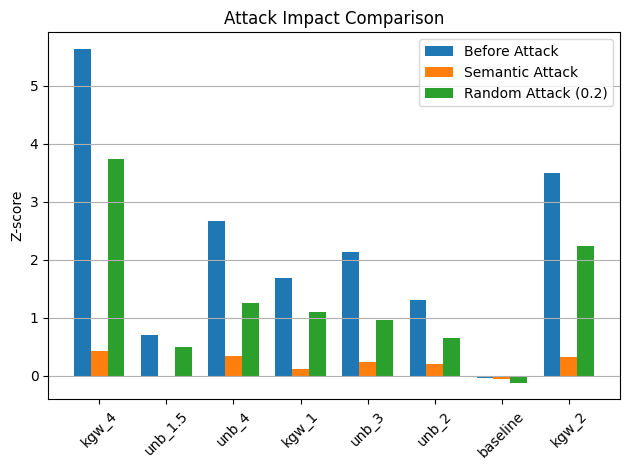

In [4]:
# =========================
# 1. 准备 semantic 数据（已有）
# =========================
df_attack = df_attack.rename(columns={
    "z_after_attack": "z_after"
})

df_before = df_det[["method", "z"]].rename(columns={
    "z": "z_before"
})

df_merge = df_before.merge(df_attack, on="method")

# =========================
# 2. 加入 random attack（关键新增）
# =========================

# 选择一个攻击强度（建议 0.2 或 0.4）
target_attack = 0.2

df_rob_sub = df_rob[df_rob["attack"] == target_attack][["method", "z"]]
df_rob_sub = df_rob_sub.rename(columns={"z": "z_random"})

# merge 进去
df_merge = df_merge.merge(df_rob_sub, on="method", how="left")

# =========================
# 3. 画图（三组柱）
# =========================
plt.figure()

x = np.arange(len(df_merge))
width = 0.25   # 👈 三组柱要变窄

plt.bar(x - width, df_merge["z_before"], width, label="Before Attack")
plt.bar(x, df_merge["z_after"], width, label="Semantic Attack")
plt.bar(x + width, df_merge["z_random"], width, label=f"Random Attack ({target_attack})")

plt.xticks(x, df_merge["method"], rotation=45)
plt.ylabel("Z-score")
plt.title("Attack Impact Comparison")
plt.legend()
plt.grid(axis="y")

plt.tight_layout()
plt.savefig("attack_combined.png", dpi=300)
plt.show()
plt.close()

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

>>> Generating baseline


Generating: 100%|██████████| 7/7 [00:18<00:00,  2.69s/it]


>>> Generating KGW delta=2


Generating: 100%|██████████| 7/7 [00:34<00:00,  4.86s/it]


...

>>> Generating Unbiased alpha=6


Generating: 100%|██████████| 7/7 [00:39<00:00,  5.68s/it]


Method baseline: Avg Z=0.0492, Avg PPL=4.6130
Method kgw_2: Avg Z=5.3322, Avg PPL=5.9132
Method kgw_3: Avg Z=7.4038, Avg PPL=7.3363
Method kgw_4: Avg Z=8.7195, Avg PPL=9.2932
Method kgw_5: Avg Z=9.4698, Avg PPL=10.7673
Method kgw_6: Avg Z=9.9188, Avg PPL=11.4560
Method unb_1.5: Avg Z=1.1041, Avg PPL=4.5539
Method unb_2: Avg Z=2.1051, Avg PPL=4.7008
Method unb_3: Avg Z=3.1462, Avg PPL=4.9098
Method unb_4: Avg Z=3.9114, Avg PPL=5.1339
Method unb_6: Avg Z=5.0372, Avg PPL=5.6597

>>> Running Semantic Attack


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

  0%|          | 0/138 [00:00<?, ?it/s]The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
100%|██████████| 138/138 [06:59<00:00,  3.04s/it]


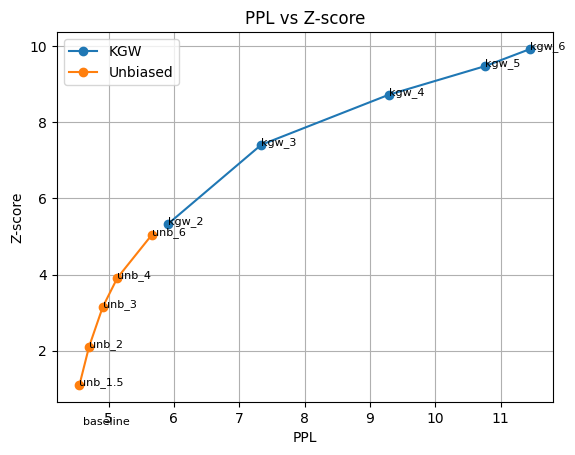

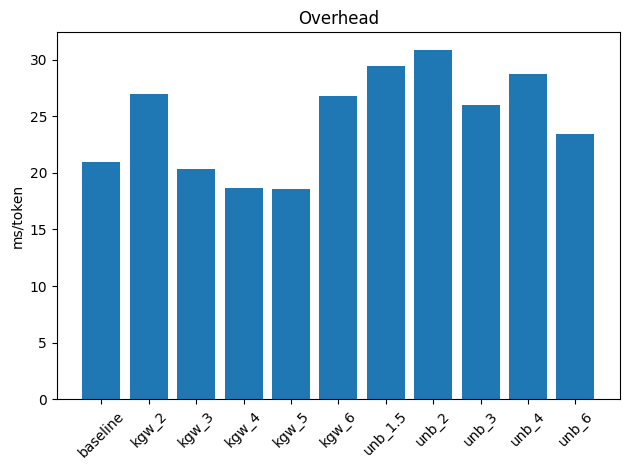

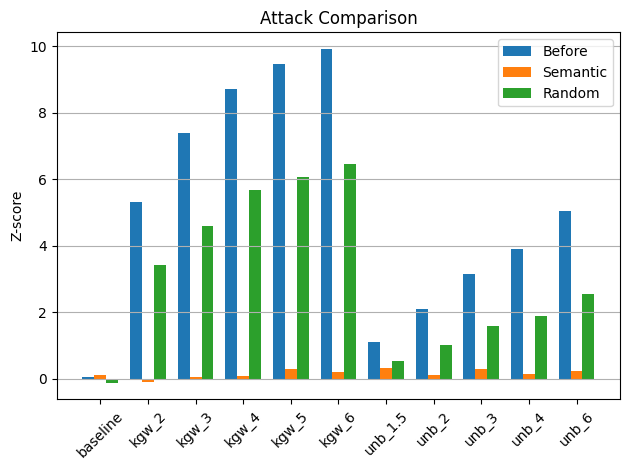

Experiment completed successfully.


In [2]:
#final_version
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import time
import torch
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
from tqdm import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer

from fc import (
    KGWLogitsProcessor, UnbiasedLogitsProcessor,
    KGWDetector, UnbiasedDetector,
    WatermarkEngine
)

# =========================
# 0. 配置
# =========================
device = "cuda"
model_path = "/root/autodl-tmp/Qwen2.5-1.5B-Instruct"

kgw_deltas = [2, 3, 4, 5, 6]
unb_alphas = [1.5, 2, 3, 4, 6]

gen_config = {
    "max_new_tokens": 128,
    "do_sample": True,
    "temperature": 0.7,
    "top_p": 0.9,
    "pad_token_id": None,
    "use_cache": True
}

# =========================
# 1. 加载模型与工具
# =========================
tokenizer = AutoTokenizer.from_pretrained(model_path, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"
gen_config["pad_token_id"] = tokenizer.pad_token_id

model = AutoModelForCausalLM.from_pretrained(
    model_path,
    torch_dtype=torch.float16,
    device_map="auto"
).eval()

engine = WatermarkEngine(model, tokenizer, device)

# 初始化检测器（确保这里的参数与 Processor 默认参数一致，如 gamma=0.5）
kgw_det = KGWDetector(tokenizer, device=device)
unb_det = UnbiasedDetector(tokenizer, device=device)

# =========================
# 2. 生成数据
# =========================
def generate_all(prompts):
    results = []
    
    # Baseline
    print(">>> Generating baseline")
    data = engine.generate(prompts, {}, gen_config, batch_size=16)
    for item in data:
        # 兼容不同版本的 engine 返回格式
        baseline_tokens = item.get("tokens", {}).get("baseline") or item.get("output_ids")
        results.append({
            "method": "baseline",
            "tokens": baseline_tokens,
            "prompt_len": item["prompt_len"]
        })

    # KGW
    for d in kgw_deltas:
        print(f">>> Generating KGW delta={d}")
        proc = KGWLogitsProcessor(gamma=0.5, delta=d, device=device)
        data = engine.generate(prompts, {"kgw": proc}, gen_config, batch_size=16)
        for item in data:
            results.append({
                "method": f"kgw_{d}",
                "tokens": item["tokens"]["kgw"],
                "prompt_len": item["prompt_len"]
            })

    # Unbiased
    for a in unb_alphas:
        print(f">>> Generating Unbiased alpha={a}")
        proc = UnbiasedLogitsProcessor(gamma=0.5, alpha=a, device=device)
        data = engine.generate(prompts, {"unbiased": proc}, gen_config, batch_size=16)
        for item in data:
            results.append({
                "method": f"unb_{a}",
                "tokens": item["tokens"]["unbiased"],
                "prompt_len": item["prompt_len"]
            })
    return results

# =========================
# 3. 指标计算 (修正核心 Bug)
# =========================
@torch.inference_mode()
def evaluate_metrics(data, batch_size=4):
    records = []
    methods = sorted(list(set(d["method"] for d in data)))

    for method in methods:
        subset = [d for d in data if d["method"] == method]
        z_list, ppl_list = [], []

        for i in range(0, len(subset), batch_size):
            batch = subset[i:i+batch_size]
            
            # 准备 PPL 计算
            input_list, label_list, mask_list = [], [], []
            valid_batch = []

            for item in batch:
                tokens = item["tokens"]
                p_len = item["prompt_len"]
                gen_tokens = tokens[p_len:]
                
                if len(gen_tokens) < 2: continue
                
                valid_batch.append(item)
                # 构造 padding
                input_list.append(torch.tensor(gen_tokens))
                label_list.append(torch.tensor(gen_tokens))

            if not input_list: continue

            # Batch Padding
            inputs = torch.nn.utils.rnn.pad_sequence(input_list, batch_first=True, padding_value=tokenizer.pad_token_id).to(device)
            labels = torch.nn.utils.rnn.pad_sequence(label_list, batch_first=True, padding_value=-100).to(device)
            masks = (inputs != tokenizer.pad_token_id).float().to(device)

            outputs = model(input_ids=inputs, attention_mask=masks, labels=labels)
            
            # 逐句计算 PPL
            logits = outputs.logits
            shift_logits = logits[:, :-1, :].contiguous()
            shift_labels = labels[:, 1:].contiguous()
            
            loss_fct = torch.nn.CrossEntropyLoss(reduction="none")
            token_losses = loss_fct(shift_logits.view(-1, shift_logits.size(-1)), shift_labels.view(-1))
            token_losses = token_losses.view(shift_labels.size())
            
            # 只对非 padding 部分求平均
            sentence_loss = token_losses.sum(dim=1) / (shift_labels != -100).sum(dim=1)
            batch_ppls = torch.exp(sentence_loss).cpu().tolist()

            # 逐条计算 Z-score (修复 z_j 未定义问题)
            det = kgw_det if "kgw" in method else unb_det
            for j, item in enumerate(valid_batch):
                # 核心修正：调用 detect 函数并获取返回值
                current_z = det.detect(item["tokens"], item["prompt_len"])
                z_list.append(current_z)
                ppl_list.append(batch_ppls[j])

        records.append({
            "method": method,
            "z": np.mean(z_list) if z_list else 0,
            "ppl": np.mean(ppl_list) if ppl_list else 0
        })
        print(f"Method {method}: Avg Z={records[-1]['z']:.4f}, Avg PPL={records[-1]['ppl']:.4f}")

    return pd.DataFrame(records)

def evaluate_overhead(prompt):
    inputs = tokenizer([prompt], return_tensors="pt").to(device)
    records = []

    configs = [("baseline", None)] + \
              [(f"kgw_{d}", KGWLogitsProcessor(0.5, d, device)) for d in kgw_deltas] + \
              [(f"unb_{a}", UnbiasedLogitsProcessor(0.5, a, device)) for a in unb_alphas]

    for name, proc in configs:
        times = []

        for _ in range(5):
            torch.cuda.synchronize()
            start = time.time()

            model.generate(
                **inputs,
                logits_processor=None if proc is None else [proc],
                max_new_tokens=64,
                do_sample=True,
                temperature=0.7,
                top_p=0.9,
                pad_token_id=tokenizer.pad_token_id,
                use_cache=True
            )

            torch.cuda.synchronize()
            times.append(time.time() - start)

        records.append({
            "method": name,
            "ms/token": np.mean(times) * 1000 / 64
        })

    df = pd.DataFrame(records)
    df.to_csv("overhead.csv", index=False)
    return df
# =========================
# 5. Random Attack
# =========================
def evaluate_random_attack(data):
    results = []
    vocab_size = len(tokenizer)
    prob = 0.2

    for item in data:
        tokens = list(item["tokens"])
        p_len = item["prompt_len"]
        if len(tokens) <= p_len: continue

        gen_tokens = np.array(tokens[p_len:])
        mask = np.random.rand(len(gen_tokens)) < prob
        gen_tokens[mask] = np.random.randint(0, vocab_size, size=mask.sum())
        
        attacked_tokens = tokens[:p_len] + gen_tokens.tolist()
        det = kgw_det if "kgw" in item["method"] else unb_det
        z = det.detect(attacked_tokens, p_len)

        results.append({"method": item["method"], "z": z})

    return pd.DataFrame(results).groupby("method")["z"].mean().reset_index()

# =========================
# 6. Semantic Attack (修正 Prompt 偏移)
# =========================
@torch.inference_mode()
def evaluate_semantic_attack(data, tokenizer, device, batch_size=8):
    print("\n>>> Running Semantic Attack")
    atk_model, atk_tokenizer = load_attack_model()
    results = []

    for i in tqdm(range(0, len(data), batch_size)):
        batch = data[i:i+batch_size]
        texts = [tokenizer.decode(item["tokens"][item["prompt_len"]:], skip_special_tokens=True) for item in batch]
        
        # 优化改写 Prompt
        prompts = [f"Paraphrase the following text: {t}\nAnswer:" for t in texts]
        inputs = atk_tokenizer(prompts, return_tensors="pt", padding=True).to(atk_model.device)

        outputs = atk_model.generate(**inputs, max_new_tokens=128, do_sample=False)
        # 提取生成部分
        decoded = [atk_tokenizer.decode(o[inputs.input_ids.shape[1]:], skip_special_tokens=True) for o in outputs]

        for item, rewritten_text in zip(batch, decoded):
            # 将改写后的文本重新 encode
            new_gen_ids = tokenizer.encode(rewritten_text, add_special_tokens=False)
            # 拼接原 prompt 和新生成的文本进行检测
            full_ids = item["tokens"][:item["prompt_len"]] + new_gen_ids
            
            det = kgw_det if "kgw" in item["method"] else unb_det
            z = det.detect(full_ids, item["prompt_len"])
            results.append({"method": item["method"], "z_after_attack": z})

    # 清理显存避免绘图崩溃
    del atk_model
    torch.cuda.empty_cache()
    
    return pd.DataFrame(results).groupby("method")["z_after_attack"].mean().reset_index()


# =========================
# 7. 画图1：PPL-Z 曲线
# =========================
def plot_tradeoff(df):
    plt.figure()

    kgw = df[df["method"].str.contains("kgw")].sort_values("method")
    unb = df[df["method"].str.contains("unb")].sort_values("method")

    plt.plot(kgw["ppl"], kgw["z"], marker='o', label="KGW")
    plt.plot(unb["ppl"], unb["z"], marker='o', label="Unbiased")

    for _, row in df.iterrows():
        plt.text(row["ppl"], row["z"], row["method"], fontsize=8)

    plt.xlabel("PPL")
    plt.ylabel("Z-score")
    plt.title("PPL vs Z-score")
    plt.legend()
    plt.grid()

    plt.savefig("ppl_z.png", dpi=300)
    plt.show()

# =========================
# 8. 画图2：Overhead
# =========================
def plot_overhead(df):
    plt.figure()

    x = np.arange(len(df))
    plt.bar(x, df["ms/token"])

    plt.xticks(x, df["method"], rotation=45)
    plt.ylabel("ms/token")
    plt.title("Overhead")

    plt.tight_layout()
    plt.savefig("overhead.png", dpi=300)
    plt.show()

# =========================
# 9. 画图3：Attack（三柱）
# =========================
def plot_attack(df_det, df_sem, df_rand):
    df = df_det[["method", "z"]].rename(columns={"z": "before"})
    df = df.merge(df_sem, on="method")
    df = df.merge(df_rand, on="method")

    df = df.rename(columns={"z": "random"})

    x = np.arange(len(df))
    w = 0.25

    plt.figure()

    plt.bar(x - w, df["before"], w, label="Before")
    plt.bar(x, df["z_after_attack"], w, label="Semantic")
    plt.bar(x + w, df["random"], w, label="Random")

    plt.xticks(x, df["method"], rotation=45)
    plt.ylabel("Z-score")
    plt.title("Attack Comparison")

    plt.legend()
    plt.grid(axis="y")

    plt.tight_layout()
    plt.savefig("attack.png", dpi=300)
    plt.show()

def main():
    with open("prompts.json") as f:
        prompts = json.load(f)["test_prompts"]# 先用少量数据测试

    data = generate_all(prompts)

    # 1. 计算基础指标
    df_det = evaluate_metrics(data)
    
    # 2. 计算开销
    df_over = evaluate_overhead(prompts[0])
    
    # 3. 攻击测试
    df_rand = evaluate_random_attack(data)
    df_sem = evaluate_semantic_attack(data, tokenizer, device)

    # 4. 可视化
    plot_tradeoff(df_det)
    plot_overhead(df_over)
    plot_attack(df_det, df_sem, df_rand)

    print("Experiment completed successfully.")

# 辅助函数：加载攻击模型
def load_attack_model():
    path = "/root/autodl-tmp/Qwen2.5-7B-Instruct" # 请确保路径正确
    tokenizer = AutoTokenizer.from_pretrained(path)
    tokenizer.pad_token = tokenizer.eos_token
    model = AutoModelForCausalLM.from_pretrained(path, torch_dtype=torch.float16, device_map="auto").eval()
    return model, tokenizer

if __name__ == "__main__":
    main()